Loading data and recreating scaler...
Loading model weights...
Total Trainable Parameters: 596,742
Running forward pass on test set...


/Users/dariogreco/STAT946/CS2/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



FINAL TEST SET METRICS (6-Hour Lead)
PatchTST MAE:      4.7822 ppb
PatchTST RMSE:     7.6743 ppb
----------------------------------------
Persistence MAE:   5.3739 ppb
Persistence RMSE:  8.6909 ppb



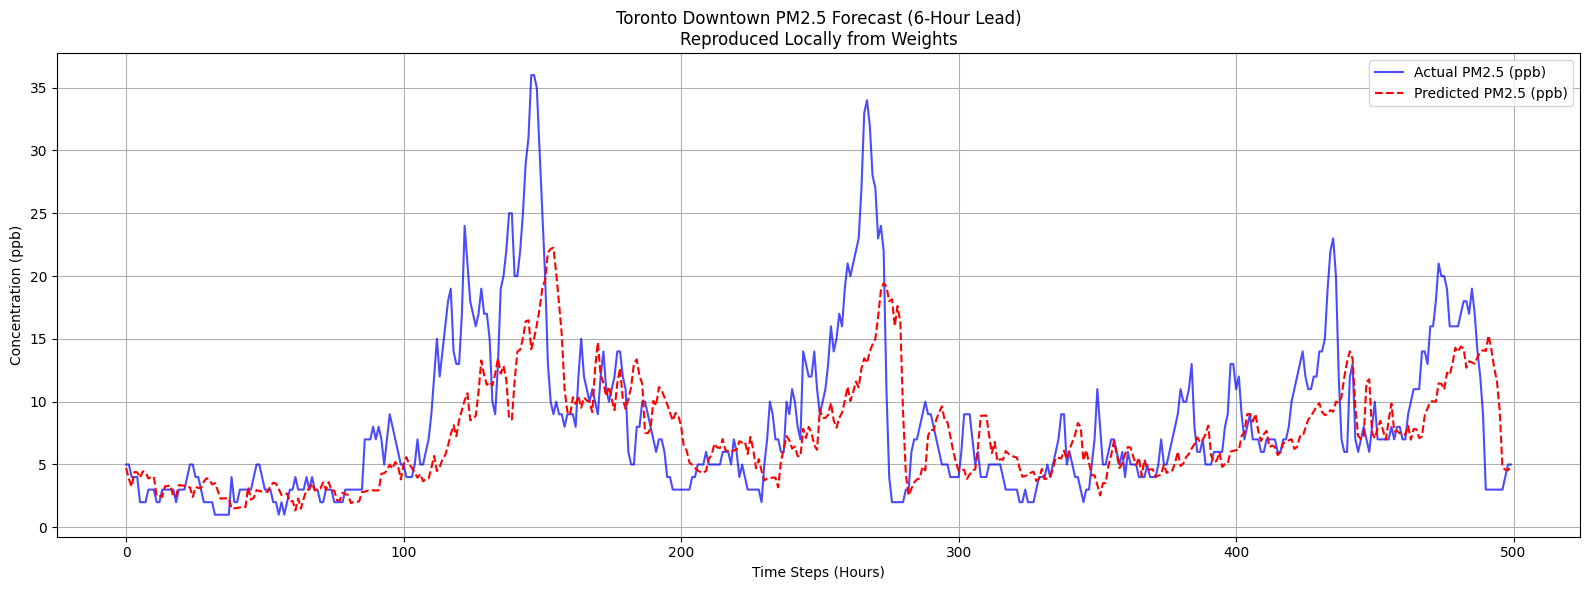

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from transformers import PatchTSTConfig, PatchTSTForPrediction

# 1. PLUG IN YOUR WINNING CONFIGURATION HERE
WINNING_LOOKBACK = 72  # Update this based on your CSV
WINNING_D_MODEL = 128  # Update this based on your CSV
WINNING_PATCH = 8      # Update this based on your CSV
WINNING_STRIDE = 4     # Update this based on your CSV
HEADS = 8

class PatchAQDataset(Dataset):
    def __init__(self, scaled_data, seq_length, forecast_horizon=6):
        self.data = scaled_data
        self.seq_length = seq_length
        self.forecast_horizon = forecast_horizon

    def __len__(self):
        return len(self.data) - self.seq_length - self.forecast_horizon

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.data[idx : idx + self.seq_length])
        y = torch.FloatTensor(self.data[idx + self.seq_length : idx + self.seq_length + self.forecast_horizon, 0])
        return x, y

def main():
    device = torch.device("cpu") 
    print("Loading data and recreating scaler...")
    
    # 2. RECREATE THE IDENTICAL SCALER
    data_path = "data/data_clean/cleaned_data_toronto_downtown.csv"
    df = pd.read_csv(data_path, low_memory=False)
    features = ['PM_ppb', 'Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Stn Press (kPa)', 'Dew Point Temp (°C)']
    
    train_size = int(len(df) * 0.7)
    scaler = StandardScaler()
    scaler.fit(df.iloc[:train_size][features])
    scaled_data_array = scaler.transform(df[features].values)

    # 3. ISOLATE THE TEST SET
    dataset = PatchAQDataset(scaled_data_array, seq_length=WINNING_LOOKBACK)
    n = len(dataset)
    val_idx = int(0.85 * n) 
    test_loader = DataLoader(Subset(dataset, range(val_idx, n)), batch_size=128, shuffle=False)

    # 4. INITIALIZE MODEL & LOAD WEIGHTS
    print("Loading model weights...")
    config = PatchTSTConfig(
        num_input_channels=6,
        context_length=WINNING_LOOKBACK, 
        prediction_length=6,
        patch_length=WINNING_PATCH, 
        stride=WINNING_STRIDE, 
        d_model=WINNING_D_MODEL, 
        num_layers=3, 
        num_attention_heads=HEADS, 
        dropout=0.1, 
        prediction_channel_indices=[0]
    )
    
    model = PatchTSTForPrediction(config)
    model.load_state_dict(torch.load("models/best_patchTST_6hr_v5.pt", map_location=device))
    model.eval()
    
    # Calculate total trainable parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    # 5. RUN INFERENCE & GET NAIVE BASELINE
    print("Running forward pass on test set...")
    preds, actuals, naive_preds = [], [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(past_values=x).prediction_outputs
            preds.append(out[:, :, 0].numpy())
            actuals.append(y.numpy())
            
            # BASELINE: The last known PM2.5 value in the lookback window
            # x shape is [batch, lookback, features]. PM2.5 is feature 0.
            # We grab the very last time step: x[:, -1, 0]
            naive_preds.append(x[:, -1, 0].numpy())

    all_p = np.vstack(preds)[:, 5]
    all_a = np.vstack(actuals)[:, 5]
    all_n = np.concatenate(naive_preds)

    # 6. CALCULATE REPRODUCIBLE METRICS
    pm_std = scaler.scale_[0]
    pm_mean = scaler.mean_[0]
    
    # Calculate exactly how it was done during training
    model_mae = mean_absolute_error(all_a, all_p) * pm_std
    model_rmse = np.sqrt(mean_squared_error(all_a, all_p)) * pm_std
    
    naive_mae = mean_absolute_error(all_a, all_n) * pm_std
    naive_rmse = np.sqrt(mean_squared_error(all_a, all_n)) * pm_std

    print("\n" + "="*40)
    print("FINAL TEST SET METRICS (6-Hour Lead)")
    print("="*40)
    print(f"PatchTST MAE:      {model_mae:.4f} ppb")
    print(f"PatchTST RMSE:     {model_rmse:.4f} ppb")
    print("-" * 40)
    print(f"Persistence MAE:   {naive_mae:.4f} ppb")
    print(f"Persistence RMSE:  {naive_rmse:.4f} ppb")
    print("="*40 + "\n")

    # 7. UNSCALE AND PLOT
    unscaled_preds = (all_p * pm_std) + pm_mean
    unscaled_actuals = (all_a * pm_std) + pm_mean
    
    plt.figure(figsize=(16, 6))
    plt.plot(unscaled_actuals[:140], label="Actual PM2.5 (ppb)", color='blue', alpha=0.7)
    plt.plot(unscaled_preds[:140], label="Predicted PM2.5 (ppb)", color='red', linestyle='--')
    plt.title(f"Toronto Downtown PM2.5 Forecast (6-Hour Lead)\nReproduced Locally from Weights")
    plt.xlabel("Time Steps (Hours)")
    plt.ylabel("Concentration (ppb)")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()